In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/housing_clean.csv"
)


df.head()

,area,bhk,metro_distance,rent
0,whitefield,1,1.5,18000
1,whitefield,2,1.5,28000
2,whitefield,3,1.5,42000
3,hsr layout,1,3.0,20000
4,hsr layout,2,3.0,32000


In [3]:
df.shape

(12, 4)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            12 non-null     str    
 1   bhk             12 non-null     int64  
 2   metro_distance  12 non-null     float64
 3   rent            12 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 654.0 bytes


In [5]:
df.isnull().sum()


area              0
bhk               0
metro_distance    0
rent              0
dtype: int64

In [6]:
area_rent = (

    df.groupby("area")
    ["rent"]
    .mean()
    .sort_values(
        ascending=False
    )

)


area_rent

area
koramangala        39333.333333
hsr layout         33333.333333
whitefield         29333.333333
electronic city    25000.000000
Name: rent, dtype: float64

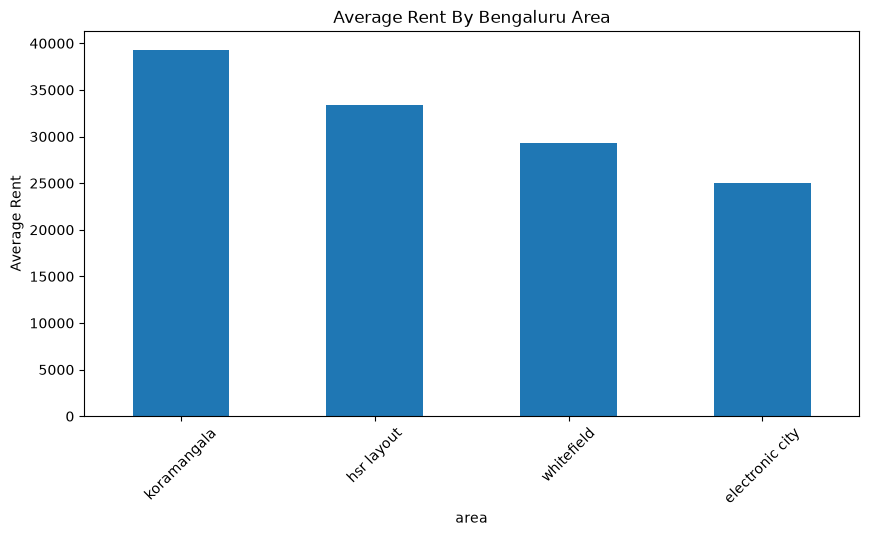

In [7]:
plt.figure(figsize=(10,5))


area_rent.plot(
    kind="bar"
)


plt.title(
    "Average Rent By Bengaluru Area"
)


plt.ylabel(
    "Average Rent"
)


plt.xticks(
    rotation=45
)



plt.show()

In [10]:
bhk_rent = (

    df.groupby("bhk")
    ["rent"]
    .mean()

)


bhk_rent

bhk
1    19500.0
2    30500.0
3    45250.0
Name: rent, dtype: float64

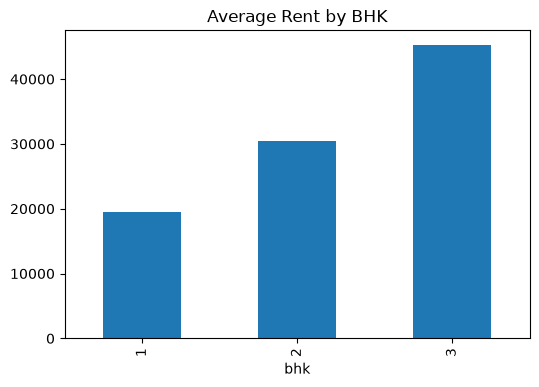

In [11]:
plt.figure(figsize=(6,4))


bhk_rent.plot(
    kind="bar"
)


plt.title(
    "Average Rent by BHK"
)


plt.show()

In [12]:
monthly_salary = 60000

In [13]:
df["affordability_score"] = (

    monthly_salary
    /
    df["rent"]

)


df.head()

,area,bhk,metro_distance,rent,affordability_score
0,whitefield,1,1.5,18000,3.333333
1,whitefield,2,1.5,28000,2.142857
2,whitefield,3,1.5,42000,1.428571
3,hsr layout,1,3.0,20000,3.000000
4,hsr layout,2,3.0,32000,1.875000


In [14]:
best_areas = (

    df.groupby("area")
    ["affordability_score"]
    .mean()
    .sort_values(
        ascending=False
    )

)


best_areas

area
electronic city    2.722222
whitefield         2.301587
hsr layout         2.041667
koramangala        1.689952
Name: affordability_score, dtype: float64